<a href="https://colab.research.google.com/github/nethuli-dev/traffic-accident-severity-prediction/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install kaggle -q

import pandas as pd      # data loading & manipulation
import numpy as np       # numerical operations
import matplotlib.pyplot as plt   # base plotting
import seaborn as sns    # nicer statistical plots, built on matplotlib
from scipy import stats  # chi-square test, correlation tests

sns.set_theme(style="whitegrid")   # makes charts readable by default
pd.set_option("display.max_columns", 100)  # don't truncate wide dataframes when printing

In [45]:
import os
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

In [11]:
!git clone https://github.com/nethuli-dev/traffic-accident-severity-prediction.git
%cd traffic-accident-severity-prediction

Cloning into 'traffic-accident-severity-prediction'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 34 (delta 12), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 154.58 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/traffic-accident-severity-prediction


In [12]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_e4fa88f4403f2b28a8581c324e0d96d6"
!kaggle datasets download -d sobhanmoosavi/us-accidents -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:06<00:00, 98.4MB/s]



In [13]:
!ls -lh data/raw

total 2.9G
-rw-r--r-- 1 root root 2.9G Aug  5 03:33 US_Accidents_March23.csv


In [14]:
#Load the dataset
df_sample = pd.read_csv("/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv", nrows=5)
print(df_sample.shape)
print(df_sample.dtypes)
print(df_sample.head())

(5, 46)
ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bu

In [15]:
#Row count
with open("/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv") as f:
    n_rows = sum(1 for _ in f) - 1
print(f"Total rows: {n_rows:,}")

Total rows: 7,728,394


In [16]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       849Mi       2.0Mi        10Gi        11Gi
Swap:             0B          0B          0B


In [17]:
#The dtype map
bool_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
    "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]
float32_cols = [
    "Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Distance(mi)",
    "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
]
category_cols = [
    "Source", "State", "Timezone", "Weather_Condition", "Wind_Direction",
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"
]

dtype_map = {}
for c in bool_cols:
    dtype_map[c] = "boolean"
for c in float32_cols:
    dtype_map[c] = "float32"
for c in category_cols:
    dtype_map[c] = "category"
dtype_map["Severity"] = "int8"

parse_dates = ["Start_Time", "End_Time", "Weather_Timestamp"]
print(f"{len(dtype_map)} columns typed, {len(parse_dates)} parsed as dates.")

35 columns typed, 3 parsed as dates.


In [18]:
#Full Load
DATA_PATH = "/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv"


In [23]:
# Load sample data from dataset
df = pd.read_csv(DATA_PATH, dtype=dtype_map, parse_dates=parse_dates, low_memory=False,
                  skiprows=lambda i: i > 0 and np.random.rand() > 0.15)
print(df.shape)
print("Memory:", round(df.memory_usage(deep=True).sum() / 1e9, 2), "GB")

(1158381, 46)
Memory: 0.86 GB


In [24]:
print(df["Severity"].value_counts(normalize=True).round(4))

Severity
2    0.7967
3    0.1679
4    0.0266
1    0.0088
Name: proportion, dtype: float64


In [25]:
# Missing Value Audit
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].round(2)
print(missing_pct)

End_Lng                  43.99
End_Lat                  43.99
Precipitation(in)        28.46
Wind_Chill(F)            25.83
Wind_Speed(mph)           7.41
Visibility(mi)            2.31
Wind_Direction            2.28
Humidity(%)               2.27
Weather_Condition         2.26
Temperature(F)            2.13
Pressure(in)              1.84
Weather_Timestamp         1.58
Sunrise_Sunset            0.30
Civil_Twilight            0.30
Astronomical_Twilight     0.30
Nautical_Twilight         0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02
City                      0.00
Description               0.00
dtype: float64


In [26]:
# Informative missingness check: does weather-field missingness cluster by state?
# (rural states with fewer weather stations should show higher missingness)
weather_cols = ["Temperature(F)", "Wind_Chill(F)", "Humidity(%)",
                 "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]

df["weather_missing_count"] = df[weather_cols].isna().sum(axis=1)

state_missingness = (
    df.groupby("State", observed=True)["weather_missing_count"]
      .mean()
      .sort_values(ascending=False)
)
print(state_missingness.head(10))   # states with worst weather-field coverage
print(state_missingness.tail(10))   # states with best coverage

State
MD    1.461196
WY    1.190731
NE    1.175194
KS    1.140989
UT    0.973997
RI    0.967466
GA    0.915027
TX    0.913478
ME    0.871391
NH    0.854194
Name: weather_missing_count, dtype: float64
State
AL    0.496578
TN    0.470749
CT    0.460000
MN    0.417510
DE    0.395872
WV    0.353559
SD    0.289474
ID    0.286678
AR    0.240850
MT    0.229071
Name: weather_missing_count, dtype: float64


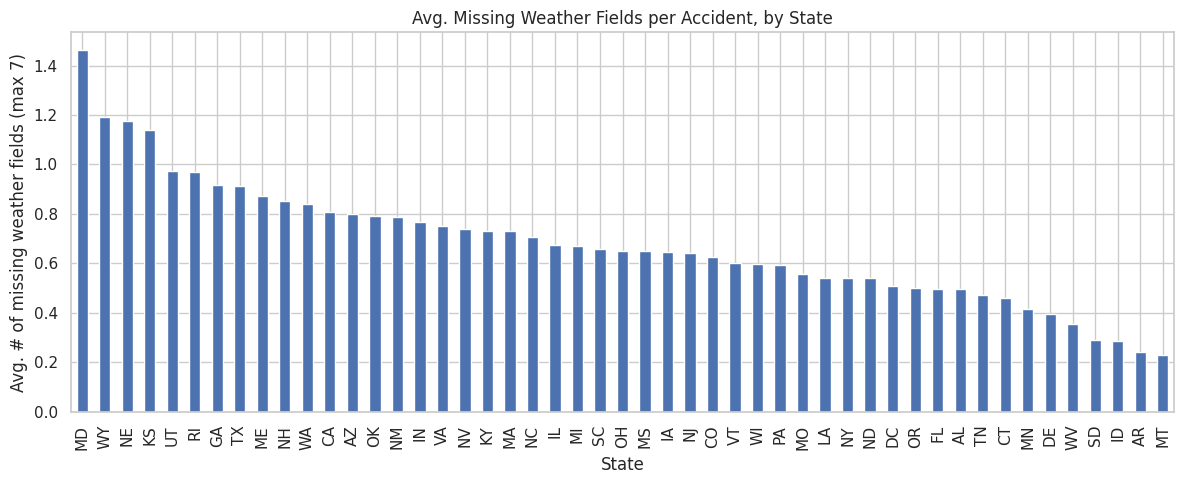

In [29]:
# Visualization
plt.figure(figsize=(12, 5))
state_missingness.sort_values(ascending=False).plot(kind="bar")
plt.title("Avg. Missing Weather Fields per Accident, by State")
plt.ylabel("Avg. # of missing weather fields (max 7)")
plt.xlabel("State")
plt.tight_layout()
plt.savefig("reports/figures/weather_missingness_by_state.png", dpi=150)
plt.show()

In [30]:
# Checking duplicates
n_dupe_ids = df["ID"].duplicated().sum()
print(f"Duplicate ID rows: {n_dupe_ids}")

# Also check for exact full-row duplicates (different issue than duplicate IDs)
n_dupe_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {n_dupe_rows}")

Duplicate ID rows: 0
Fully duplicate rows: 0


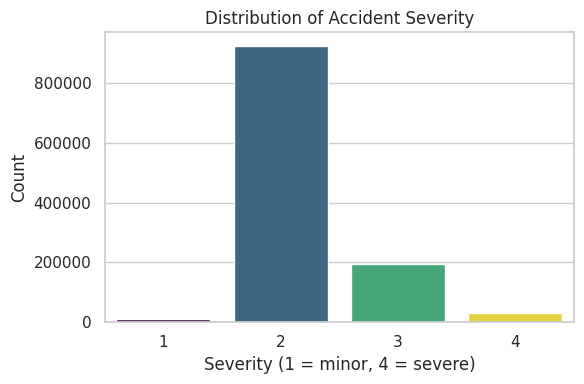

In [31]:
# Severity Distribution Chart
plt.figure(figsize=(6, 4))
sns.countplot(x="Severity", data=df, order=[1, 2, 3, 4], hue="Severity",
              palette="viridis", legend=False)
plt.title("Distribution of Accident Severity")
plt.xlabel("Severity (1 = minor, 4 = severe)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("reports/figures/severity_distribution.png", dpi=150)
plt.show()

In [32]:
print(df["Start_Time"].dtype)
print(df["Start_Time"].head(3))

object
0    2016-02-08 06:49:27
1    2016-02-08 07:39:07
2    2016-02-08 08:14:42
Name: Start_Time, dtype: object


In [33]:
# Explicitly parse datetime columns (read_csv's parse_dates silently didn't take effect)
for col in ["Start_Time", "End_Time", "Weather_Timestamp"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes)

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object


In [34]:
print("Unparseable Start_Time rows:", df["Start_Time"].isna().sum())

Unparseable Start_Time rows: 111203


In [35]:
df["hour"] = df["Start_Time"].dt.hour

In [36]:
#Hour-of-day vs severity(Chi-square)

df["hour"] = df["Start_Time"].dt.hour

def hour_bucket(h):
    if 6 <= h < 10: return "morning_rush"
    elif 10 <= h < 16: return "midday"
    elif 16 <= h < 19: return "evening_rush"
    elif 19 <= h < 23: return "evening"
    else: return "overnight"

df["hour_bucket"] = df["hour"].apply(hour_bucket)

contingency = pd.crosstab(df["hour_bucket"], df["Severity"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.4g}, dof: {dof}")

# Effect size (Cramér's V) — chi-square alone is misleading at this row count,
# since even trivial associations become "significant" with 1M+ rows
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square: 21370.46, p-value: 0, dof: 12
Cramér's V: 0.0784


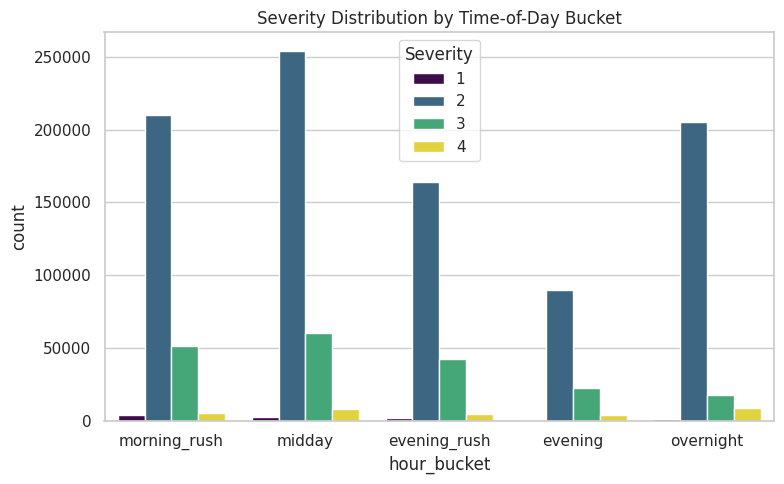

In [37]:
#Visualization for Severity Distribution by Time-of-Day Bucket
plt.figure(figsize=(8, 5))
sns.countplot(x="hour_bucket", hue="Severity",
              order=["morning_rush", "midday", "evening_rush", "evening", "overnight"],
              data=df, palette="viridis")
plt.title("Severity Distribution by Time-of-Day Bucket")
plt.tight_layout()
plt.savefig("reports/figures/severity_by_hour_bucket.png", dpi=150)
plt.show()

In [38]:
#Weather vs severity

top_weather = df["Weather_Condition"].value_counts().head(10).index
weather_subset = df[df["Weather_Condition"].isin(top_weather)]

contingency_w = pd.crosstab(weather_subset["Weather_Condition"], weather_subset["Severity"])
chi2_w, p_w, dof_w, _ = stats.chi2_contingency(contingency_w)
n_w = contingency_w.sum().sum()
cramers_v_w = np.sqrt(chi2_w / (n_w * (min(contingency_w.shape) - 1)))
print(f"Weather -> Severity | Chi2: {chi2_w:.2f}, p: {p_w:.4g}, Cramér's V: {cramers_v_w:.4f}")

mean_sev_by_weather = df.groupby("Weather_Condition", observed=True)["Severity"].mean().sort_values(ascending=False)
print(mean_sev_by_weather.head(15))

Weather -> Severity | Chi2: 53025.27, p: 0, Cramér's V: 0.1292
Weather_Condition
Heavy Ice Pellets                      3.000000
Light Snow Grains                      3.000000
Light Thunderstorm                     3.000000
Squalls                                3.000000
Rain and Sleet                         3.000000
Low Drifting Snow                      3.000000
Light Snow Showers                     2.750000
Hail                                   2.666667
Rain Showers                           2.590909
Light Ice Pellets                      2.538462
Smoke / Windy                          2.529412
Rain Shower                            2.500000
Ice Pellets                            2.500000
Light Sleet / Windy                    2.500000
Heavy Thunderstorms with Small Hail    2.500000
Name: Severity, dtype: float64


In [39]:
#Geographic clustering — severity rate relative to volume, not raw count

state_stats = df.groupby("State", observed=True).agg(
    total_accidents=("Severity", "count"),
    severe_rate=("Severity", lambda s: (s >= 3).mean())
).sort_values("severe_rate", ascending=False)

print(state_stats.head(10))   # highest severe-accident RATE, not just volume

       total_accidents  severe_rate
State                              
RI                2459     0.471330
GA               25561     0.438324
KY                4859     0.432599
WI                5088     0.390134
CO               13574     0.377707
MO               11747     0.368520
IL               25204     0.362363
NM                1594     0.338770
IA                4007     0.330921
VT                 141     0.319149


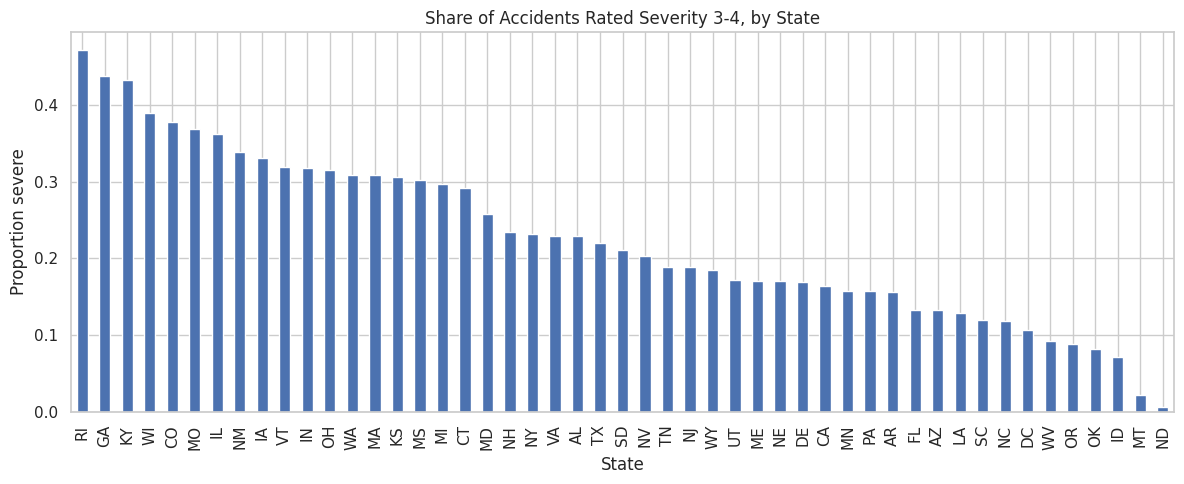

In [40]:
#Visualization for Share of Accidents Rated Severity 3-4, by State
plt.figure(figsize=(12, 5))
state_stats.sort_values("severe_rate", ascending=False)["severe_rate"].plot(kind="bar")
plt.title("Share of Accidents Rated Severity 3-4, by State")
plt.ylabel("Proportion severe")
plt.tight_layout()
plt.savefig("reports/figures/severe_rate_by_state.png", dpi=150)
plt.show()

Spearman correlation, Distance(mi) vs Severity: -0.137


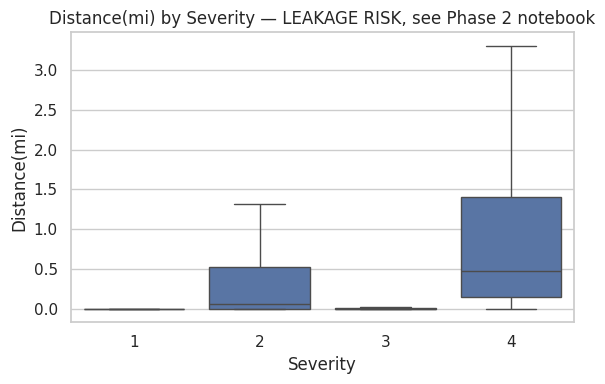

In [41]:
#Distance(mi) leakage flag — quantify it now, decide in Phase 2
distance_corr = df[["Distance(mi)", "Severity"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation, Distance(mi) vs Severity: {distance_corr:.3f}")

plt.figure(figsize=(6, 4))
sns.boxplot(x="Severity", y="Distance(mi)", data=df, showfliers=False)
plt.title("Distance(mi) by Severity — LEAKAGE RISK, see Phase 2 notebook")
plt.tight_layout()
plt.savefig("reports/figures/distance_leakage_flag.png", dpi=150)
plt.show()

In [46]:
# Save the sampled dataframe so Phase 2+ notebooks load the SAME sample
# instead of re-reading the full 2.9GB CSV every time
df.to_parquet("data/processed/accidents_sample.parquet", index=False)
print(f"Saved {df.shape[0]:,} rows to data/processed/accidents_sample.parquet")

Saved 1,158,381 rows to data/processed/accidents_sample.parquet


In [42]:
%cd /content/traffic-accident-severity-prediction
!pwd

/content/traffic-accident-severity-prediction
/content/traffic-accident-severity-prediction
